# Exploratory Data Analysis | FD001 - C-MAPPS simulation
We begin reading the FD001 training subset of the C-MAPPS simulation. Each file contains time-series measurements from 21 sensors along with three operating condition settings. The dataset has no header row, so we assign column names manually

### Setup: Package Imports

1. Load Data

In [1]:
# load dataset
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# project
from xai_aviation_rul.data_loader import load_cmapps
from xai_aviation_rul.preprocessor import compute_rul, drop_constant_sensors, normalize, get_last_cycle
from xai_aviation_rul.visualizer import (
    plot_rul_distribution,
    plot_sensor_trends,
    plot_sensor_variance,
    plot_correlation_heatmap,
    save_table_as_figure,
)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# load dataset
df_train = load_cmapps(fd=1, subset="train")
df_test  = load_cmapps(fd=1, subset="test")

In [3]:
# show head and shapes
display(df_train.head())
print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

,unit_number,time_in_cycles,op-setting_1,op-setting_2,op-setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Training set shape: (20631, 26)
Test set shape: (13096, 26)


2. Dataset Statistics

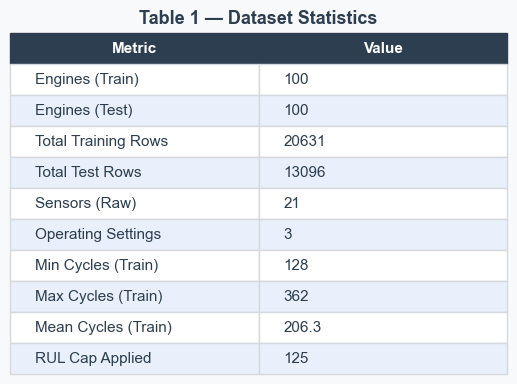

In [4]:
# dataset statistics table
# Dataset Statistics Table
cycles_per_engine = df_train.groupby("unit_number")["time_in_cycles"].max()

stats_table = pd.DataFrame([{
    "Engines (Train)": int(df_train["unit_number"].nunique()),
    "Engines (Test)": int(df_test["unit_number"].nunique()),
    "Total Training Rows": int(len(df_train)),
    "Total Test Rows": int(len(df_test)),
    "Sensors (Raw)": 21,
    "Operating Settings": 3,
    "Min Cycles (Train)": int(cycles_per_engine.min()),
    "Max Cycles (Train)": int(cycles_per_engine.max()),
    "Mean Cycles (Train)": round(float(cycles_per_engine.mean()), 1),
    "RUL Cap Applied": 125,
}]).T.rename(columns={0: "Value"}).rename_axis("Metric")

save_table_as_figure(
    stats_table,
    save_path=FIG_DIR / "table1_dataset_statistics.png",
    title="Table 1 — Dataset Statistics"
)

3. Compute RUL

In [5]:
# computer RUL
df_train = compute_rul(df_train, rul_cap=125)
display(df_train.loc[:, ["unit_number", "time_in_cycles", "RUL", "RUL_capped"]].head(5))

,unit_number,time_in_cycles,RUL,RUL_capped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125


4. Sensor Variance Analysis

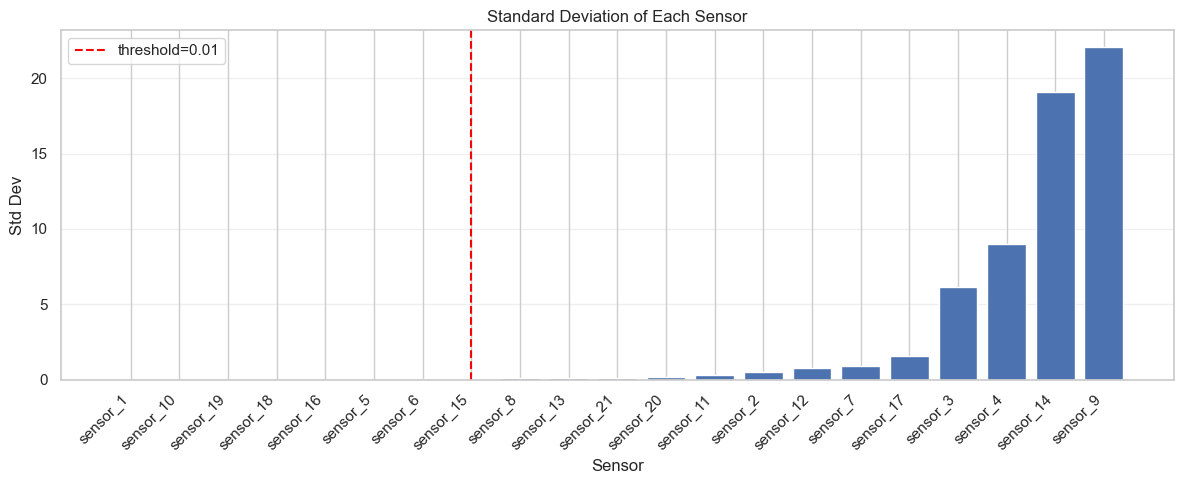

In [6]:
# sensor variance analysis 
plot_sensor_variance(df_train, save_path=FIG_DIR / "fig_sensor_variance.png")

5. Drop Constant Sensors

In [7]:
# drop constant sensors
before_sensors = [c for c in df_train.columns if c.startswith("sensor_")]

# call drop_constant_sensors — handle either return types (df or (df, dropped))
result = drop_constant_sensors(df_train, threshold=0.01)
if isinstance(result, tuple) and len(result) == 2:
    df_train, dropped_list = result
else:
    df_train = result
    after_sensors = [c for c in df_train.columns if c.startswith("sensor_")]
    dropped_list = sorted(set(before_sensors) - set(after_sensors))

remaining_sensors = sorted([c for c in df_train.columns if c.startswith("sensor_")])

print("Dropped sensors:", dropped_list)
print("Remaining sensors:", remaining_sensors)

Dropped sensors: ['sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5', 'sensor_6']
Remaining sensors: ['sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_2', 'sensor_20', 'sensor_21', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9']


6. Normalization

In [8]:
# normalization
train_scaled, test_scaled, scaler = normalize(df_train.copy(), df_test.copy())
df_train = train_scaled
df_test = test_scaled
print("Normalization complete - scaler fitted on training sensors and applied to test.")

Normalization complete - scaler fitted on training sensors and applied to test.


7. RUL Distribution

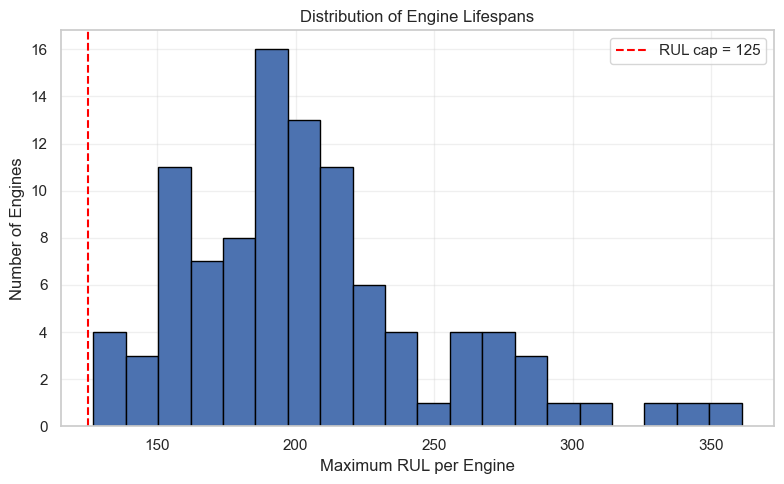

In [9]:
# RUL distribution  
plot_rul_distribution(df_train, save_path=FIG_DIR / "fig_rul_distribution.png")

8. Sensor Degradation Trends

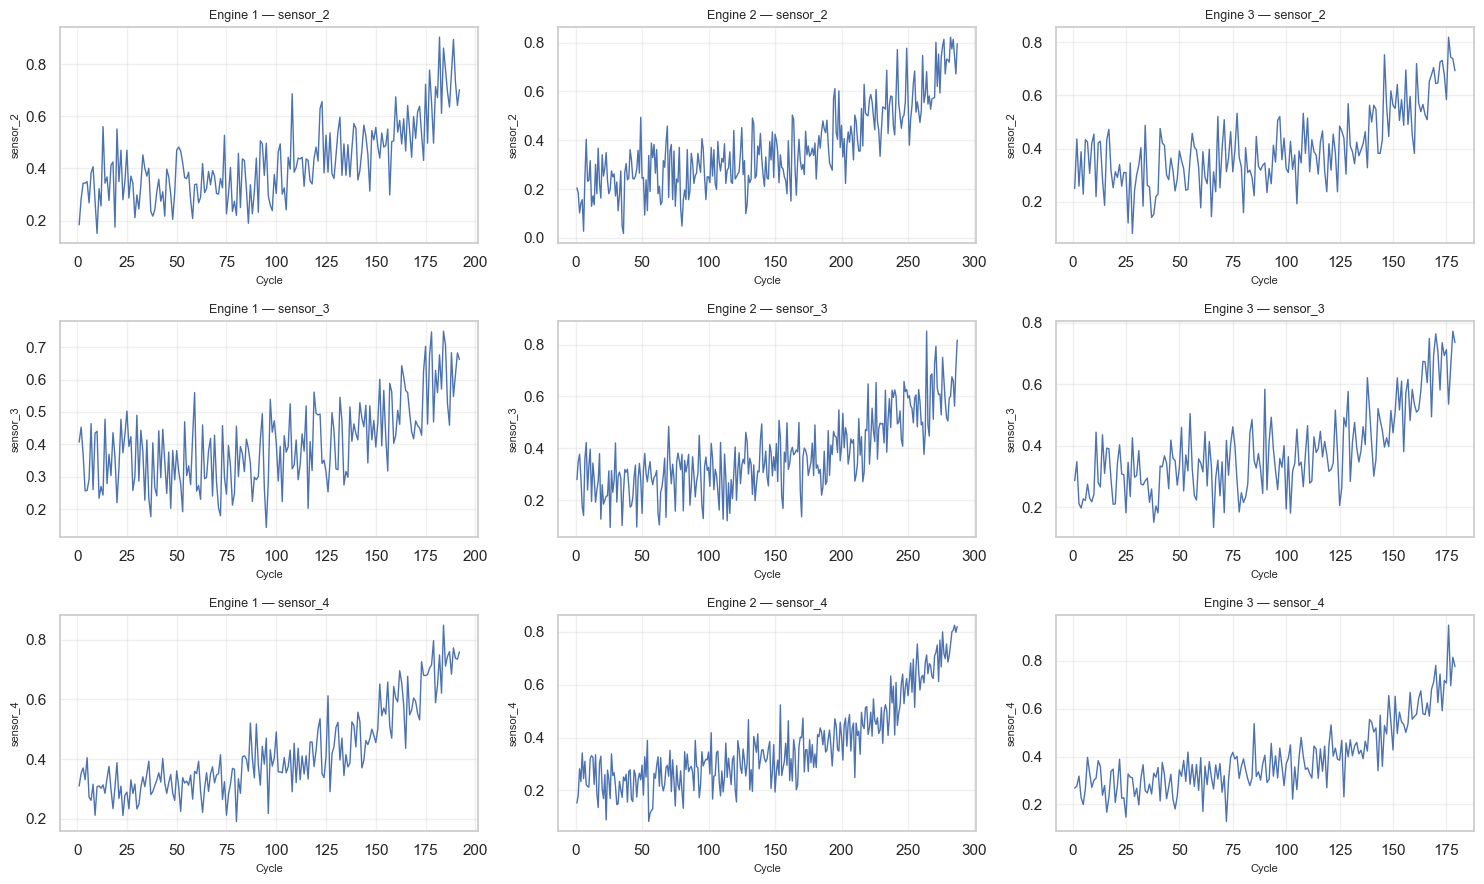

In [10]:
# sensor degradation trends
sensor_cols_to_plot = ["sensor_2", "sensor_3", "sensor_4"]
plot_sensor_trends(df_train, engine_ids=[1, 2, 3], sensor_cols=sensor_cols_to_plot, save_path=FIG_DIR / "fig_sensor_trends.png")

9. Correlation Heatmap

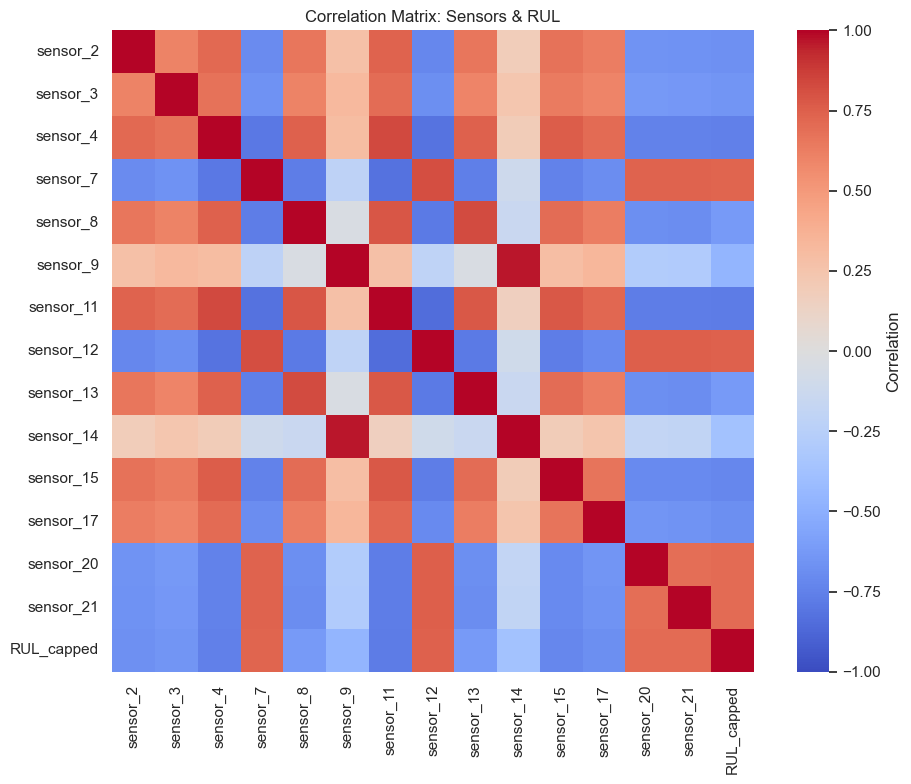

In [11]:
# correlation heatmap
plot_correlation_heatmap(df_train, save_path=FIG_DIR / "fig_correlation_heatmap.png")